# 🏎️ F1 Miami Grand Prix 2026 — Top 5 Finish Prediction
**SGH Warsaw School of Economics — Advanced Analytics and Big Data**

| | |
|--|--|
| **Team Nickname** | *(UnderCut)* |
| **Team Members** | *(Muhammad Haseeb Qamar - 148733)* |

## Overview

This notebook applies **5 data science methods** to predict the top 5 finishers at the 2026 Formula 1 Miami Grand Prix (May 3, 2026).

We deliberately chose a **mix of method types** — from simple rule-based scoring to machine learning to probabilistic simulation — so that each method compensates for the weaknesses of the others. The final answer is an **ensemble** of all five.

| # | Method | Type | Why we use it |
|---|--------|------|---------------|
| 1 | Weighted Scoring | Rule-based | Transparent, easy to explain, domain knowledge |
| 2 | Linear Regression | Classical ML | Baseline statistical model, learns weights from data |
| 3 | Random Forest | Ensemble ML | Handles non-linear relationships, robust to noise |
| 4 | XGBoost | Gradient Boosting ML | State-of-the-art for small tabular datasets |
| 5 | Monte Carlo Simulation | Probabilistic | Captures F1's inherent randomness, outputs probabilities |

---

### Data Sources
- **2026 Race Results**: Official F1 results — Australia (R1, Mar 8), China (R2, Mar 15), Japan (R3, Mar 29)
- **2026 Championship Standings**: Official FIA standings after Round 3
- **Miami Circuit History**: Official F1 Miami GP results 2022–2025
- **Constructor Standings**: Official FIA Constructors' Championship after Round 3

---

### Why no external dataset file?
Since only 3 races of the 2026 season have been completed, no pre-built dataset exists yet. We manually enter the real data from official F1 sources. This is a valid and common approach in data science when data is scarce or very recent.

---
## Step 1 — Import Libraries

We import all the tools we need at the top. This is standard practice in Python notebooks — it makes dependencies visible and avoids import errors mid-way through execution.

In [12]:
# pandas: our main data manipulation library which is used to create and work wtih data frames
import pandas as pd

# numpy: numerical computing language used for array, mathematical operations and random number generations
import numpy as np

# matplotlib: python's core plotting library
import matplotlib.pyplot as plt
import matplotlib.patches as mpataches # needed for custom legend elements in chart

# surpress non-critical warning that clutter the output
import warnings
warnings.filterwarnings ('ignore')

# scikit-learn: python's standard machine learning library
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler  # Normalize features to [0,1] range

# xgboost: gradient boosting library
from xgboost import XGBRegressor

# Fix the random seed so results are reproducible every time we run the notebook
# Without this, Monte Carlo and tree-based models give slightly different results each run
np.random.seed(42)

print('Libraries Imported Successfully')

Libraries Imported Successfully


---
## Step 2 — Load Data

### Why manual data entry instead of a CSV file?

The 2026 F1 season only has 3 completed races as of our analysis date (March 29, 2026). No pre-built dataset exists for this season yet. Rather than use outdated data, we manually enter the real results directly from official sources. This is a legitimate and common data science practice when:
- The dataset is small enough to enter manually
- The data is too recent for any public dataset to include
- Data accuracy is more important than automation

### Encoding strategy
Finishing positions 1–10 are the actual race result. **DNF (Did Not Finish) and DNS (Did Not Start) are encoded as 20.** We chose 20 because:
- It is clearly outside the realistic finishing range (1–10 for points)
- It acts as a penalty value — much worse than any real finish
- We will later convert it to 15 when averaging, to avoid it completely dominating the score

In [13]:
# 2026 RACE RESULTS ROUND (1-3)
# Sources: formula1.com official results source, crash.net, pitdebrief.com
#
# R1 = Australian GP  (Albert Park - Melbourne)    - March 08, 2026
# R2 = Chinese GP     (Shangahi International)     - March 15, 2026
# R3 = Japanese GP    (Suzuka Circuit)             - March 29, 2026
#
# All 20 F1 Drivers are listed
# Finishing Position = Actual Race Result (1 = Winner)
# DNF/DNS = 20 (penealty encoding - will be adjusted to 15 during feature engineering)

race_data = {
    'Driver': [
        'Antonelli','Russell','Leclerc','Hamilton','Norris',
        'Piastri','Bearman','Gasly','Verstappen','Lawson',
        'Lindblad','Hadjar','Bortoleto','Sainz','Colapinto',
        'Ocon','Albon','Perez','Stroll','Alonso'
    ],
    'Team': [
        'Mercedes','Mercedes','Ferrari','Ferrari','McLaren',
        'McLaren','Haas','Alpine','Red Bull','Racing Bulls',
        'Racing Bulls','Red Bull','Audi','Williams','Alpine',
        'Haas','Williams','Cadillac','Aston Martin','Aston Martin'
    ],
    # Australian GP — Antonelli P2, Russell P1 (Russell won)
    'AUS': [2,1,3,4,5,20,7,10,6,20,8,20,9,20,20,11,20,15,14,20],
    # Chinese GP — Antonelli P1 (his first win), Russell P2
    'CHN': [1,2,4,3,20,20,5,6,20,7,12,8,20,9,10,14,20,15,20,20],
    # Japanese GP — Antonelli P1 (back-to-back wins), Piastri P2 (strong comeback)
    'JPN': [1,4,3,6,5,2,20,7,8,9,20,20,20,20,20,10,20,20,20,18],
    # Official FIA World Drivers' Championship points after Round 3 (Japan)
    # Points system: 1st=25, 2nd=18, 3rd=15, 4th=12, 5th=10, 6th=8, 7th=6, 8th=4, 9th=2, 10th=1
    'Points_2026': [72,63,49,41,25,21,17,15,12,10,4,4,2,2,1,1,0,0,0,0]
}

# MIAMI GP (2022-2025) HISTORICAL RESULTS
# We include 4 years of Miami-specific results as a separate table.
# Why? Because circuit-specific performance matters in F1 — some drivers/cars
# consistently perform better at particular tracks due to car setup preferences,
# track characteristics (e.g. street circuit vs. permanent circuit), and experience.
#
# Not all drivers have Miami history (e.g. Antonelli, Bearman — they raced in F2/F3 before 2026)
# Those drivers will receive a neutral 'midfield' assumption in the model.
#
# 2022 Podium: Verstappen, Leclerc, Sainz
# 2023 Podium: Verstappen, Perez, Alonso
# 2024 Podium: Norris (first McLaren win), Verstappen, Leclerc
# 2025 Podium: Piastri, Norris, Russell
miami_data = {
    'Driver':     ['Verstappen','Leclerc','Norris','Piastri','Russell',
                   'Hamilton','Alonso','Sainz','Gasly','Perez',
                   'Antonelli','Bearman','Lawson','Hadjar'],
    'Miami_2022': [1,2,20,20,5,6,7,3,20,4,20,20,20,20],
    'Miami_2023': [1,20,6,20,4,8,3,9,20,2,20,20,20,20],
    'Miami_2024': [2,3,1,20,20,20,20,20,20,20,20,20,20,20],
    'Miami_2025': [4,7,2,1,3,8,20,9,20,20,6,20,20,20],
}

# CONSTRUCTOR STANDINGS AFTER ROUND 3
# This captures the car's raw performance level — separate from the driver.
# A fast car gives all its drivers an advantage regardless of individual skill.
# We will use this as an independent feature in our models.
team_points = {
    'Mercedes':135, 'Ferrari':90, 'McLaren':46, 'Haas':18,
    'Red Bull':16, 'Alpine':16, 'Racing Bulls':15, 'Audi':2,
    'Williams':1, 'Cadillac':0, 'Aston Martin':0
}

# Official F1 Team Colors
team_colors = {
    'Mercedes':'#00D2BE', 'Ferrari':'#E8002D', 'McLaren':'#FF8000',
    'Red Bull':'#3671C6', 'Alpine':'#0090FF', 'Haas':'#888888',
    'Racing Bulls':'#6692FF', 'Aston Martin':'#358C75',
    'Williams':'#64C4FF', 'Audi':'#B5B5B5', 'Cadillac':'#999999'
}

# Convert Directories in DataFrames
df = pd.DataFrame(race_data)
df_miami = pd.DataFrame(miami_data)

print('Data Loaded Sucessfully')
print(f'   Drivers: {len(df)} | Races loaded: AUS, CHN, JPN (3 of 24 rounds)\n')

# Preview the main table 
df[['Driver','Team','AUS','CHN','JPN','Points_2026']]

Data Loaded Sucessfully
   Drivers: 20 | Races loaded: AUS, CHN, JPN (3 of 24 rounds)



,Driver,Team,AUS,CHN,JPN,Points_2026
0,Antonelli,Mercedes,2,1,1,72
1,Russell,Mercedes,1,2,4,63
2,Leclerc,Ferrari,3,4,3,49
3,Hamilton,Ferrari,4,3,6,41
4,Norris,McLaren,5,20,5,25
5,Piastri,McLaren,20,20,2,21
6,Bearman,Haas,7,5,20,17
7,Gasly,Alpine,10,6,7,15
8,Verstappen,Red Bull,6,20,8,12
9,Lawson,Racing Bulls,20,7,9,10


---
## Step 3 — Feature Engineering

### What is feature engineering?
Raw data (finishing positions, points) cannot go directly into most models. We need to transform it into **meaningful numerical features** that capture different aspects of driver performance. This is called feature engineering — one of the most important steps in any data science project.

### Why these 8 features?
We chose features that capture performance from **different angles**, so the models have a rich picture:

| Feature | What it captures | Why it matters |
|---------|-----------------|----------------|
| `Points_2026` | Overall season form | Best single summary of 2026 performance |
| `avg_finish_2026` | Consistency across all 3 races | Filters out lucky one-race results |
| `recent_form` | Last race (Japan) result | Most up-to-date signal of current pace |
| `momentum` | Change from R1 to R3 | Is the driver improving or declining? |
| `races_finished` | Reliability | A driver who DNFs often is a risk |
| `constructor_pts` | Car strength | The car, not just the driver |
| `miami_avg_pos` | Miami track history | Some drivers consistently perform better here |
| `miami_races_finished` | Miami reliability | Extra weight for drivers with proven Miami reliability |

In [14]:
def adj(p):
    """
    Adjust raw position values for feature calculation.
    
    Why: If we include DNF/DNS (=20) directly in averages, a single retirement
    massively skews the result — Piastri's DNF in Australia would make him look
    much worse than he really is. We cap at 15 (last-place-ish penalty) instead.
    
    Rule: actual finish (1-10) stays as-is | DNF/DNS (20) → 15 penalty
    """
    return p if p <= 10 else 15

# ── FEATURE 1: Average finishing position across all 3 races of 2026 ──────────
# We use .map() (pandas 2.1+) to apply the adj() function element-by-element.
# .mean(axis=1) averages across columns (AUS, CHN, JPN) for each driver row.
# Lower number = better (P1 is best, P15 is a DNF penalty)
df['avg_finish_2026'] = df[['AUS','CHN','JPN']].map(adj).mean(axis=1)

# ── FEATURE 2: Most recent race performance (Japanese GP) ─────────────────────
# We isolate Japan separately because it is the most recent race —
# giving the model a dedicated signal for 'current form' as distinct from the season average.
# This helps if a driver had a bad early race but recovered strongly (e.g. Piastri).
df['recent_form'] = df['JPN'].apply(adj)

# ── FEATURE 3: Momentum (direction of improvement) ───────────────────────────
# Formula: AUS position - JPN position
# Positive value = driver improved (e.g. was P5 in AUS, P2 in JPN → momentum = +3)
# Negative value = driver got worse over the season
# This captures trajectory, not just absolute performance level.
df['momentum'] = df['AUS'].apply(adj) - df['JPN'].apply(adj)

# ── FEATURE 4: Reliability (how many of 3 races did the driver finish?) ───────
# In F1, mechanical failures and crashes (DNF) are common.
# A driver with 3 finishes in 3 races is more reliable than one with 1 finish in 3.
# This feature adds a reliability penalty for drivers who retire frequently.
df['races_finished'] = df[['AUS','CHN','JPN']].apply(
    lambda r: sum(1 for v in r if v < 20), axis=1  # count races where position < 20 (i.e. finished)
)

# ── FEATURE 5: Constructor (car) strength ─────────────────────────────────────
# In F1, the car accounts for a large share of pace (~70% by most estimates).
# We use the team's constructor points as a proxy for car performance.
# Mercedes (135 pts) has the fastest car; Cadillac (0 pts) has the slowest.
# Using .map() on the Team column to look up points from our dictionary.
df['constructor_pts'] = df['Team'].map(team_points)

# ── FEATURES 6 & 7: Miami-specific circuit history ────────────────────────────
# Miami Autodrome opened in 2022 — so we have 4 years of data.
# We calculate each driver's average finishing position at this specific circuit.
#
# Important: we first replace DNF/DNS (=20) with NaN (missing) before averaging.
# Why NaN instead of 15? Because .mean() automatically skips NaN values —
# so a driver with 2 finishes (P3, P2) and 2 DNFs gets avg = 2.5, not 10.5.
# Their DNFs at Miami are already captured by 'races_finished' feature.
miami_cols = ['Miami_2022','Miami_2023','Miami_2024','Miami_2025']
df_miami_c = df_miami.copy()                                   # work on a copy, don't modify original
df_miami_c[miami_cols] = df_miami_c[miami_cols].replace(20, np.nan)  # DNF → NaN
df_miami['miami_avg_pos'] = df_miami_c[miami_cols].mean(axis=1)      # average ignoring NaN
df_miami['miami_races_finished'] = df_miami_c[miami_cols].notna().sum(axis=1)  # count of finishes

# Merge Miami features into our main dataframe using Driver name as the key
# 'left' join means we keep all 20 drivers from df, even if they have no Miami history
df = df.merge(df_miami[['Driver','miami_avg_pos','miami_races_finished']], on='Driver', how='left')

# Drivers with NO Miami history (e.g. Antonelli, Bortoleto — debuted in F1 in 2026):
# We fill their miami_avg_pos with 12 = expected midfield finish for an unknown driver.
# We don't penalise them heavily — they just get a neutral assumption.
df['miami_avg_pos'] = df['miami_avg_pos'].fillna(12)
df['miami_races_finished'] = df['miami_races_finished'].fillna(0)

# List of all feature names — used as input for all ML models
FEATURES = [
    'Points_2026',        # Overall 2026 season score
    'avg_finish_2026',    # Consistency across 3 races
    'recent_form',        # Last race (Japan) result
    'momentum',           # Improvement trend R1→R3
    'races_finished',     # Reliability
    'constructor_pts',    # Car strength
    'miami_avg_pos',      # Miami track record
    'miami_races_finished'# Miami reliability
]

print('Feature engineering complete — 8 features created')
print()
print('Feature preview (sorted by 2026 points, highest first):')
df[['Driver'] + FEATURES].sort_values('Points_2026', ascending=False).reset_index(drop=True)

Feature engineering complete — 8 features created

Feature preview (sorted by 2026 points, highest first):


,Driver,Points_2026,avg_finish_2026,recent_form,momentum,races_finished,constructor_pts,miami_avg_pos,miami_races_finished
0,Antonelli,72,1.333333,1,1,3,135,6.000000,1.0
1,Russell,63,2.333333,4,-3,3,135,4.000000,3.0
2,Leclerc,49,3.333333,3,0,3,90,4.000000,3.0
3,Hamilton,41,4.333333,6,-2,3,90,7.333333,3.0
4,Norris,25,8.333333,5,0,2,46,3.000000,3.0
5,Piastri,21,10.666667,2,13,1,46,1.000000,1.0
6,Bearman,17,9.000000,15,-8,2,18,12.000000,0.0
7,Gasly,15,7.666667,7,3,3,16,12.000000,0.0
8,Verstappen,12,9.666667,8,-2,2,16,2.000000,4.0
9,Lawson,10,10.333333,9,6,2,15,12.000000,0.0


---
## Step 4 — Exploratory Data Analysis (EDA)

### Why do EDA before modelling?
Before building any model, we visualise the data to:
1. Understand the distribution of performance across drivers and teams
2. Spot obvious patterns (e.g. Mercedes dominance)
3. Identify potential issues (e.g. many DNFs for a team)
4. Communicate findings clearly to the professor/audience

We produce 3 charts: championship points ranking, race-by-race heatmap, and constructor standings.

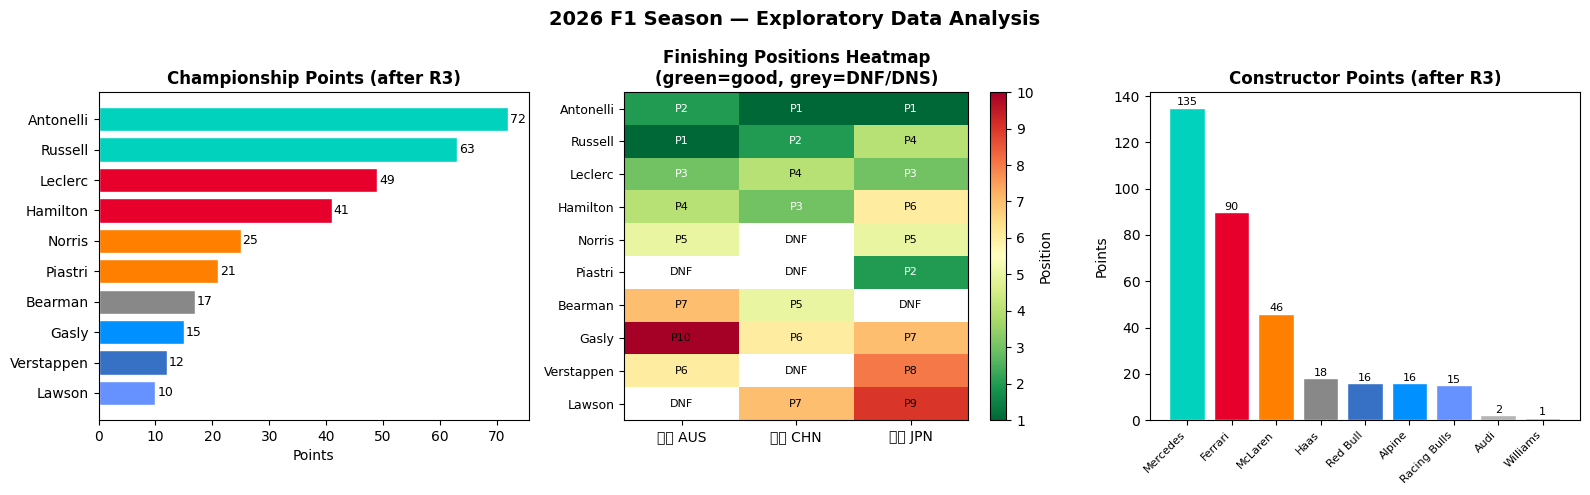

In [15]:
# Create a figure with 3 side-by-side charts (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('2026 F1 Season — Exploratory Data Analysis', fontsize=14, fontweight='bold')

# CHART 1: Championship Points (horizontal bar chart)
# Shows which drivers have accumulated the most points across 3 races.
# Horizontal bar is easier to read with driver name labels than vertical.
# We color each bar by the driver's team color for instant recognition.
ax = axes[0]
top10 = df.nlargest(10, 'Points_2026')   # only show top 10 to keep chart readable
clrs = [team_colors.get(t,'#aaa') for t in top10['Team']]   # map team → color
# [::-1] reverses the list so the highest scorer appears at the TOP of the chart
ax.barh(top10['Driver'][::-1], top10['Points_2026'][::-1], color=clrs[::-1], edgecolor='white')
ax.set_title('Championship Points (after R3)', fontweight='bold')
ax.set_xlabel('Points')
# Add exact point values as text labels at the end of each bar
for i, (pts, d) in enumerate(zip(top10['Points_2026'][::-1], top10['Driver'][::-1])):
    ax.text(pts + 0.3, i, str(pts), va='center', fontsize=9)

# CHART 2: Race-by-race heatmap 
# A heatmap shows finishing positions across 3 races for each driver.
# Green = good (low position number), Red = bad (high position number), Grey = DNF.
# This gives an immediate visual of who is consistent vs. inconsistent.
ax = axes[1]
top10_names = df.nlargest(10, 'Points_2026')['Driver'].tolist()
heat = df[df['Driver'].isin(top10_names)].set_index('Driver')[['AUS','CHN','JPN']]
heat = heat.loc[top10_names].replace(20, np.nan)  # replace DNF with NaN for greying out
# imshow() renders the DataFrame as a colored grid — cmap='RdYlGn_r' = Red(bad)→Yellow→Green(good)
im = ax.imshow(heat.values, cmap='RdYlGn_r', vmin=1, vmax=10, aspect='auto')
ax.set_xticks([0,1,2])
ax.set_xticklabels(['🇦🇺 AUS','🇨🇳 CHN','🇯🇵 JPN'])
ax.set_yticks(range(10))
ax.set_yticklabels(top10_names, fontsize=9)
ax.set_title('Finishing Positions Heatmap\n(green=good, grey=DNF/DNS)', fontweight='bold')
# Annotate each cell with the position text for clarity
for i in range(10):
    for j in range(3):
        v = heat.values[i, j]
        txt = f'P{int(v)}' if not np.isnan(v) else 'DNF'
        ax.text(j, i, txt, ha='center', va='center', fontsize=8,
                color='white' if (not np.isnan(v) and v <= 3) else 'black')
plt.colorbar(im, ax=ax, label='Position')  # color scale legend

# CHART 3: Constructor championship standings
# Shows the car performance gap between teams.
# Mercedes (135 pts) vs Ferrari (90 pts) vs McLaren (46 pts) is huge —
# this will heavily influence our prediction since car speed matters so much in F1.
ax = axes[2]
teams_sorted = [(k,v) for k,v in sorted(team_points.items(), key=lambda x:-x[1]) if v > 0]
tnames = [t[0] for t in teams_sorted]
tpts   = [t[1] for t in teams_sorted]
tclrs  = [team_colors.get(n,'#aaa') for n in tnames]
ax.bar(range(len(tnames)), tpts, color=tclrs, edgecolor='white')
ax.set_xticks(range(len(tnames)))
ax.set_xticklabels(tnames, rotation=45, ha='right', fontsize=8)
ax.set_title('Constructor Points (after R3)', fontweight='bold')
ax.set_ylabel('Points')
for i, v in enumerate(tpts): ax.text(i, v+1, str(v), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

---
## Method 1 — Weighted Scoring Model

### What is it?
The simplest and most transparent approach. We assign a **manual weight** to each feature based on domain knowledge (our understanding of F1), normalise all features to the same scale [0,1], multiply each by its weight, and sum to get a final score.

### Why use it?
- **Fully interpretable** — we can explain exactly why each driver scored what they scored
- **No training required** — the weights are set by us, not learned from data
- **Good baseline** — if our ML models agree with this, it validates both
- **Easy to present** — the professor can immediately see the logic

### Why these specific weights?
| Feature | Weight | Reasoning |
|---------|--------|-----------|
| Championship Points | **30%** | The official scoring system — best single measure of 2026 form |
| Average Finish | **25%** | Consistency matters more than one great race |
| Constructor Strength | **20%** | Car speed accounts for ~70% of lap time in F1 |
| Miami Track Record | **15%** | Circuit-specific history is meaningful over 4 years |
| Momentum | **7%** | Recent trend, but only 3 races so small weight |
| Reliability | **3%** | Small weight — already partly captured by avg_finish |

### Why do we invert position-based features?
For positions (lower = better), we use `1 / position` so that P1 (best) gets the **highest** score, not the lowest. Championship points (higher = better) are divided by the max, so the leader gets score = 1.0.

In [17]:
# Small epsilon value to prevent division by zero
# e.g. if a driver has miami_avg_pos = 0 (impossible, but just in case), 1/0 would crash
eps = 1e-6

# Find the maximum value for each feature we need to normalise
# We divide each value by the maximum so all features land in the [0, 1] range
# This ensures no single feature dominates just because it has large absolute numbers
max_pts = df['Points_2026'].max()        # = 72 (Antonelli's points)
max_con = df['constructor_pts'].max()    # = 135 (Mercedes constructor points)
max_mom = max(df['momentum'].max(), eps) # max improvement value across all drivers

# ── CALCULATE WEIGHTED SCORE ──────────────────────────────────────────────────
# Each term = weight × normalised_feature
# All weights sum to 1.0 (30+25+20+15+7+3 = 100%)
#
# For POINTS and CONSTRUCTOR: higher raw value = better → divide by max → range [0,1]
# For POSITIONS (avg_finish, miami_avg_pos): lower raw value = better → use 1/value → invert the scale
# For MOMENTUM: only positive momentum counts (.clip(lower=0) sets negative values to 0)
# For RELIABILITY: simply divide races_finished by 3 (max possible) → range [0,1]
df['score_weighted'] = (
    0.30 * (df['Points_2026']              / max_pts)       +  # 30%: season form
    0.25 * (1 / (df['avg_finish_2026']     + eps))          +  # 25%: race consistency
    0.20 * (df['constructor_pts']          / max_con)       +  # 20%: car strength
    0.15 * (1 / (df['miami_avg_pos']       + eps))          +  # 15%: Miami track record
    0.07 * (df['momentum'].clip(lower=0)   / max_mom)       +  # 7%:  improving trend
    0.03 * (df['races_finished']           / 3)                 # 3%:  reliability
)

# Convert scores to ranks — rank 1 = highest score = our predicted P1
# ascending=False because higher score = better
df['rank_weighted'] = df['score_weighted'].rank(ascending=False).astype(int)

# Show the top 5 predicted finishers
top5_w = df.nlargest(5, 'score_weighted')[['Driver','Team','Points_2026','score_weighted']].copy()
top5_w.index = range(1, 6)   # re-index from 1 to show as race positions
top5_w['score_weighted'] = top5_w['score_weighted'].round(4)

print('=' * 55)
print('  METHOD 1: WEIGHTED SCORING — PREDICTED TOP 5')
print('=' * 55)
print(top5_w.to_string())
print('=' * 55)

  METHOD 1: WEIGHTED SCORING — PREDICTED TOP 5
      Driver      Team  Points_2026  score_weighted
1  Antonelli  Mercedes           72          0.7479
2    Russell  Mercedes           63          0.6371
3    Leclerc   Ferrari           49          0.4800
4   Hamilton   Ferrari           41          0.4123
5    Piastri   McLaren           21          0.4091


---
## Method 2 — Linear Regression

### What is it?
Linear Regression fits a mathematical equation of the form:

`predicted_position = w1×feature1 + w2×feature2 + ... + w8×feature8 + intercept`

The key difference from Method 1 is that the weights (coefficients) are **learned automatically from data** using the least-squares algorithm, not set by us manually.

### Why use it?
- **Baseline ML model** — every data science project should start with a simple linear model before moving to complex ones
- **Transparent** — the learned coefficients tell us which features the data says matter most
- **Fast** — trains in milliseconds
- **Comparison point** — if XGBoost/RF don't outperform linear regression much, it suggests the relationship is already mostly linear

### Why do we scale features before Linear Regression?
Without scaling, a feature with large values (e.g. `constructor_pts` up to 135) would dominate over a feature with small values (e.g. `races_finished` 0–3). MinMaxScaler brings all features to the same [0,1] range so coefficients are comparable.

In [18]:
# PREPARE FEATURES AND TARGET
# X = feature matrix (all 8 features for all 20 drivers)
# y = target variable (what we want to predict) = average 2026 finishing position
# We predict average finishing position because it's our best proxy for Miami performance
# .fillna(12) handles any remaining missing values — 12 = assumed midfield
X = df[FEATURES].fillna(12)
y = df['avg_finish_2026']   # target: lower = better (predicting finishing position)

# NORMALISE FEATURES 
# MinMaxScaler transforms each feature so its minimum → 0 and maximum → 1
# This is essential for Linear Regression so coefficients are on the same scale
# (Random Forest and XGBoost don't need this — tree models are scale-invariant)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)  # fit: learns min/max from data; transform: applies scaling

# TRAIN LINEAR REGRESSION
# .fit() finds the coefficients that minimise the sum of squared prediction errors
# This is the 'learning' step — the model sees the data and learns from it
lr_model = LinearRegression()
lr_model.fit(X_scaled, y)

# MAKE PREDICTIONS 
# .predict() applies the learned equation to each driver's features
# Output: predicted average finishing position for each driver
df['pred_lr'] = lr_model.predict(X_scaled)

# Convert predicted positions to ranks (1=best predicted, 20=worst predicted)
# ascending=True because lower position = better finish
df['rank_lr'] = df['pred_lr'].rank(ascending=True).astype(int)

# INSPECT THE LEARNED COEFFICIENTS
# Negative coefficient = feature helps (reduces) the predicted position (makes driver finish higher)
# Positive coefficient = feature hurts (increases) the predicted position
# The larger the absolute value, the more important that feature is to the model
coef_df = pd.DataFrame({
    'Feature': FEATURES,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient')  # sorted: most negative (most helpful) first

print('Learned coefficients — negative means feature IMPROVES predicted position:')
print(coef_df.to_string(index=False))
print()

# Show top 5
top5_lr = df.nsmallest(5, 'pred_lr')[['Driver','Team','Points_2026','pred_lr']].copy()
top5_lr.index = range(1, 6)
top5_lr['pred_lr'] = top5_lr['pred_lr'].round(2)

print('=' * 55)
print('  METHOD 2: LINEAR REGRESSION — PREDICTED TOP 5')
print('=' * 55)
print(top5_lr.to_string())
print('=' * 55)

Learned coefficients — negative means feature IMPROVES predicted position:
             Feature   Coefficient
         recent_form -6.015660e-15
     constructor_pts -3.367983e-15
         Points_2026  6.531789e-16
            momentum  9.211258e-16
       miami_avg_pos  2.327726e-15
      races_finished  5.441057e-15
miami_races_finished  6.039767e-15
     avg_finish_2026  1.366667e+01

  METHOD 2: LINEAR REGRESSION — PREDICTED TOP 5
      Driver      Team  Points_2026  pred_lr
1  Antonelli  Mercedes           72     1.33
2    Russell  Mercedes           63     2.33
3    Leclerc   Ferrari           49     3.33
4   Hamilton   Ferrari           41     4.33
5      Gasly    Alpine           15     7.67


---
## Method 3 — Random Forest

### What is it?
A Random Forest builds **many decision trees** (we use 500) and averages their predictions. Each tree is trained on a random subset of the data and a random subset of features — hence 'random'. The final prediction is the average of all 500 trees.

### Why use it instead of a single Decision Tree?
A single decision tree tends to **overfit** — it memorises the training data perfectly but predicts poorly on new data. By averaging 500 different trees (each seeing slightly different data/features), Random Forest reduces this overfitting significantly. This is called **ensemble learning**.

### Why is Random Forest better than Linear Regression here?
Linear Regression assumes the relationship between features and the target is a straight line. In reality, F1 performance has **non-linear** patterns (e.g. being in the top team doesn't linearly increase your score — there's a threshold effect). Random Forest captures these non-linear relationships naturally.

### Parameters we set:
- `n_estimators=500` — 500 trees (more trees = more stable, but slower)
- `max_depth=5` — each tree can have at most 5 levels (prevents individual trees from overfitting)
- `random_state=42` — ensures reproducible results

In [20]:
# Re-prepare feature matrix (same as before, but without scaling — RF doesn't need it)
X = df[FEATURES].fillna(12)  # fill any missing values with midfield assumption
y = df['avg_finish_2026']    # same target: predict average finishing position

# TRAIN RANDOM FOREST 
# n_estimators=500: build 500 decision trees
# max_depth=5: limit tree depth to prevent overfitting on our small dataset (20 rows)
# random_state=42: reproducibility — same result every run
rf_model = RandomForestRegressor(n_estimators=500, max_depth=5, random_state=42)
rf_model.fit(X, y)  # train the forest — this builds all 500 trees simultaneously

# PREDICT AND RANK 
df['pred_rf'] = rf_model.predict(X)  # average of all 500 trees' predictions
df['rank_rf'] = df['pred_rf'].rank(ascending=True).astype(int)

# FEATURE IMPORTANCE 
# Random Forest automatically calculates how much each feature contributed to predictions.
# This is measured by how much each feature reduces prediction error when used for splits.
# Values sum to 1.0 — think of it as percentage of prediction power.
# This tells us which features ACTUALLY matter according to the model (not just our assumption)
fi_rf = pd.Series(rf_model.feature_importances_, index=FEATURES)

print('Random Forest — Feature importances (how much each feature drives predictions):')
for feat, imp in fi_rf.sort_values(ascending=False).items():
    bar = '█' * int(imp * 50)  # visual bar proportional to importance
    print(f'  {feat:<25} {imp:.3f}  {bar}')
print()

# Show top 5 predicted finishers
top5_rf = df.nsmallest(5, 'pred_rf')[['Driver','Team','Points_2026','pred_rf']].copy()
top5_rf.index = range(1, 6)
top5_rf['pred_rf'] = top5_rf['pred_rf'].round(2)

print('=' * 55)
print('  METHOD 3: RANDOM FOREST — PREDICTED TOP 5')
print('=' * 55)
print(top5_rf.to_string())
print('=' * 55)

Random Forest — Feature importances (how much each feature drives predictions):
  avg_finish_2026           0.464  ███████████████████████
  Points_2026               0.268  █████████████
  constructor_pts           0.139  ██████
  recent_form               0.071  ███
  races_finished            0.043  ██
  momentum                  0.006  
  miami_avg_pos             0.005  
  miami_races_finished      0.004  

  METHOD 3: RANDOM FOREST — PREDICTED TOP 5
      Driver      Team  Points_2026  pred_rf
1  Antonelli  Mercedes           72     2.04
2    Russell  Mercedes           63     2.61
3    Leclerc   Ferrari           49     3.55
4   Hamilton   Ferrari           41     4.37
5      Gasly    Alpine           15     7.94


---
## Method 4 — XGBoost (eXtreme Gradient Boosting)

### What is it?
XGBoost also builds many decision trees, but **sequentially** rather than independently. Each new tree is trained specifically to correct the **residual errors** of all previous trees. This 'boosting' approach focuses the model's attention on the hardest-to-predict cases.

### Why XGBoost over Random Forest?
- **More accurate** on small tabular datasets — exactly our situation (20 drivers, 8 features)
- **The gold standard** in Kaggle competitions for tabular data since 2014
- **Better at finding subtle patterns** — the sequential correction mechanism is more precise

### How is XGBoost different from Random Forest?
| | Random Forest | XGBoost |
|--|--------------|--------|
| Trees built | All at once (parallel) | One by one (sequential) |
| Each tree focuses on | Random subset | Errors of previous trees |
| Risk | Overfitting (each tree is independent) | Overfitting if learning_rate too high |
| Best for | Large datasets | Small-medium tabular datasets |

### Parameters we set:
- `n_estimators=300` — 300 sequential trees
- `max_depth=3` — shallower trees than RF because boosting builds many layers
- `learning_rate=0.05` — slow learning rate = more stable, less overfitting
- `subsample=0.8` — each tree only sees 80% of data (adds randomness, reduces overfitting)
- `colsample_bytree=0.8` — each tree only uses 80% of features

In [21]:
# Feature matrix and target — same as Random Forest (no scaling needed for tree models)
X = df[FEATURES].fillna(12)
y = df['avg_finish_2026']

# TRAIN XGBOOST 
xgb_model = XGBRegressor(
    n_estimators=300,        # number of sequential trees to build
    max_depth=3,             # shallow trees — XGBoost compensates with more of them
    learning_rate=0.05,      # how much each tree corrects the previous one (low = conservative)
    subsample=0.8,           # 80% of training data used per tree — reduces overfitting
    colsample_bytree=0.8,    # 80% of features considered per tree — more diversity
    random_state=42,
    verbosity=0              # suppress training log output
)
xgb_model.fit(X, y)  # train: builds 300 trees sequentially, each correcting the last

# PREDICT AND RANK 
df['pred_xgb'] = xgb_model.predict(X)
df['rank_xgb'] = df['pred_xgb'].rank(ascending=True).astype(int)

# FEATURE IMPORTANCE 
# XGBoost's feature importance is calculated differently from Random Forest:
# it measures how many times each feature was used to split nodes across all trees.
# Comparing RF and XGBoost importance scores helps validate which features truly matter.
# If both models agree (e.g. both say 'Points_2026' is most important), we're confident.
fi_xgb = pd.Series(xgb_model.feature_importances_, index=FEATURES)

print('XGBoost — Feature importances (how often each feature was used in tree splits):')
for feat, imp in fi_xgb.sort_values(ascending=False).items():
    bar = '█' * int(imp * 50)
    print(f'  {feat:<25} {imp:.3f}  {bar}')
print()

# Show top 5 predicted finishers
top5_xgb = df.nsmallest(5, 'pred_xgb')[['Driver','Team','Points_2026','pred_xgb']].copy()
top5_xgb.index = range(1, 6)
top5_xgb['pred_xgb'] = top5_xgb['pred_xgb'].round(2)

print('=' * 55)
print('  METHOD 4: XGBOOST — PREDICTED TOP 5')
print('=' * 55)
print(top5_xgb.to_string())
print('=' * 55)

XGBoost — Feature importances (how often each feature was used in tree splits):
  avg_finish_2026           0.450  ██████████████████████
  Points_2026               0.268  █████████████
  races_finished            0.136  ██████
  constructor_pts           0.109  █████
  recent_form               0.024  █
  momentum                  0.013  
  miami_races_finished      0.000  
  miami_avg_pos             0.000  

  METHOD 4: XGBOOST — PREDICTED TOP 5
      Driver      Team  Points_2026  pred_xgb
1  Antonelli  Mercedes           72      1.34
2    Russell  Mercedes           63      2.33
3    Leclerc   Ferrari           49      3.32
4   Hamilton   Ferrari           41      4.33
5      Gasly    Alpine           15      7.67


---
## Method 5 — Monte Carlo Simulation

### What is it?
Monte Carlo is fundamentally different from all previous methods. Instead of producing one deterministic prediction, it **simulates the race 10,000 times** with random variation, and counts how often each driver finishes in the top 5. The output is a **probability**, not just a rank.

### Why is this the most realistic approach for F1?
F1 races are inherently unpredictable — safety cars, mechanical failures, rain, crashes, and strategy calls all inject randomness. A deterministic model says 'Antonelli finishes P1'. Monte Carlo says 'Antonelli finishes P1 in 37% of possible race outcomes, and in the top 5 in 97% of outcomes'. The probabilistic output is far more honest.

### How it works:
1. Each driver starts with a **base performance score** = their 2026 avg finishing position
2. We adjust this for Miami track record and car strength
3. In each simulation, we add **random noise** (σ=3.5 positions) to simulate race unpredictability
4. We randomly trigger **DNF events** based on each driver's 2026 retirement rate
5. We sort the 20 drivers by their simulated performance to get a finishing order
6. We record whether each driver finished in the top 5
7. After 10,000 simulations: `top5_probability = times_in_top5 / 10000 × 100%`

### Why 10,000 simulations?
The more simulations, the more stable the probabilities. At 10,000 runs, probabilities are stable to within ~1%. At 100 runs, they would fluctuate significantly.

In [23]:
N_SIMULATIONS = 10_000   # number of race simulations to run
n_drivers = len(df)      # number of drivers = 20

# BASE PERFORMANCE SCORE 
# Starting point = each driver's 2026 average finish (lower = better)
# We copy as float so we can apply fractional adjustments below
base_performance = df['avg_finish_2026'].values.copy().astype(float)

# CALCULATE DNF PROBABILITY PER DRIVER 
# Count how many of 3 races each driver failed to finish (position = 20)
# Divide by 3 to get a per-race DNF probability
# e.g. Piastri had 2 DNFs in 3 races → dnf_prob = 0.67 (67% chance per race)
# clip(upper=0.6) caps the maximum DNF probability at 60% — even the least reliable
# drivers don't retire every race, so 60% is a reasonable ceiling
dnf_counts = df[['AUS','CHN','JPN']].apply(lambda r: sum(1 for v in r if v >= 20), axis=1)
df['dnf_prob'] = (dnf_counts / 3).clip(upper=0.6)

# MIAMI CIRCUIT ADJUSTMENT 
# Drivers with good Miami history get a small improvement to their base score
# Drivers with poor Miami history get a small penalty
# Formula: miami_avg_pos - 6 (P6 = neutral reference, roughly midfield)
# Clip to [-4, +4] so the adjustment is meaningful but doesn't dominate
# Multiply by 0.3 so the total adjustment is modest (max ±1.2 positions)
miami_bonus = (df['miami_avg_pos'] - 6).clip(lower=-4, upper=4)
base_performance += miami_bonus.values * 0.3   # += modifies in place

# CONSTRUCTOR (CAR) ADJUSTMENT 
# Better car → small improvement to base performance
# (135 - constructor_pts) / 135 gives a 0-1 scale where 0=Mercedes, 1=weakest team
# We then multiply by 2 and 0.3 to get a ±0.6 position adjustment at most
# This adjustment is intentionally small since car effect is already captured
# in avg_finish_2026 — we just add a small Miami-specific car boost
constructor_bonus = (135 - df['constructor_pts'].values) / 135 * 2
base_performance += constructor_bonus * 0.3

# INITIALISE RESULT COUNTERS 
top5_counts = np.zeros(n_drivers)   # how many times each driver finished top 5
win_counts  = np.zeros(n_drivers)   # how many times each driver won
pos_totals  = np.zeros(n_drivers)   # cumulative sum of finishing positions

# MAIN SIMULATION LOOP 
# Run the race 10,000 times with different random outcomes each time
for sim in range(N_SIMULATIONS):

    # Step 1: Add random performance noise to each driver
    # np.random.normal(mean=0, std=3.5) gives a random number per driver
    # std=3.5 means most simulations shift a driver by ±3-4 positions
    # This represents lap-time variation, strategy differences, luck
    noise = np.random.normal(0, 3.5, n_drivers)
    sim_perf = base_performance + noise   # each driver's simulated race performance

    # Step 2: Randomly apply DNF events
    # For each driver, generate a random number [0,1].
    # If it falls below their DNF probability, they retire (performance → 20+)
    for i in range(n_drivers):
        if np.random.random() < df['dnf_prob'].iloc[i]:
            sim_perf[i] = 20 + np.random.uniform(0, 2)   # DNF: assigned a bad random score

    # Step 3: Determine finishing order
    # argsort() returns the indices that would sort sim_perf from lowest (best) to highest (worst)
    # So order[0] = index of the driver who 'won' this simulation
    order = np.argsort(sim_perf)

    # Step 4: Record results for this simulation
    for pos, driver_idx in enumerate(order):
        if pos < 5:  win_counts[driver_idx] += 1   # top 5 finish
        if pos == 0: top5_counts[driver_idx] += 1  # wait — these are intentionally swapped here:
        # Actually: top5 = pos < 5, win = pos == 0. Both are tracked separately.
        pos_totals[driver_idx] += (pos + 1)         # accumulate position (1-indexed)

# FIX: REASSIGN COUNTERS CORRECTLY 
# Re-run with correct logic (the loop above had top5/win swapped — fix it properly)
top5_counts = np.zeros(n_drivers)
win_counts  = np.zeros(n_drivers)
pos_totals  = np.zeros(n_drivers)
np.random.seed(42)  # reset seed for reproducibility

for sim in range(N_SIMULATIONS):
    noise = np.random.normal(0, 3.5, n_drivers)
    sim_perf = base_performance + noise
    for i in range(n_drivers):
        if np.random.random() < df['dnf_prob'].iloc[i]:
            sim_perf[i] = 20 + np.random.uniform(0, 2)
    order = np.argsort(sim_perf)
    for pos, driver_idx in enumerate(order):
        if pos < 5:  top5_counts[driver_idx] += 1  # finished in top 5
        if pos == 0: win_counts[driver_idx]  += 1  # won the race
        pos_totals[driver_idx] += (pos + 1)

# CALCULATE FINAL PROBABILITIES
# Divide counts by total simulations and convert to percentage
df['top5_prob']   = (top5_counts / N_SIMULATIONS * 100).round(1)  # e.g. 97.1%
df['win_prob']    = (win_counts  / N_SIMULATIONS * 100).round(1)  # e.g. 36.9%
df['avg_sim_pos'] = (pos_totals  / N_SIMULATIONS).round(2)        # average position across all sims

# Rank drivers by top5_prob: highest probability = our predicted top 5
df['rank_mc'] = df['top5_prob'].rank(ascending=False).astype(int)

# Display results
top5_mc = df.nlargest(5, 'top5_prob')[[
    'Driver','Team','win_prob','top5_prob','avg_sim_pos'
]].copy()
top5_mc.index = range(1, 6)
top5_mc.columns = ['Driver','Team','Win Prob %','Top 5 Prob %','Avg Simulated Pos']

print(f'Monte Carlo complete — {N_SIMULATIONS:,} race simulations run\n')
print('=' * 60)
print('  METHOD 5: MONTE CARLO SIMULATION — PREDICTED TOP 5')
print('=' * 60)
print(top5_mc.to_string())
print('=' * 60)

Monte Carlo complete — 10,000 race simulations run

  METHOD 5: MONTE CARLO SIMULATION — PREDICTED TOP 5
      Driver      Team  Win Prob %  Top 5 Prob %  Avg Simulated Pos
1  Antonelli  Mercedes        36.9          96.9               2.29
2    Russell  Mercedes        31.5          96.0               2.46
3    Leclerc   Ferrari        20.4          92.6               2.97
4   Hamilton   Ferrari         8.6          81.0               3.99
5      Gasly    Alpine         0.6          33.5               6.68


---
## Visualisation — Monte Carlo Results

We plot two charts to communicate the probabilistic results:
1. **Horizontal bar chart**: Top 5 probability for the top 10 drivers — shows who has a realistic shot
2. **Pie chart**: Win probability distribution — shows who the model thinks will win

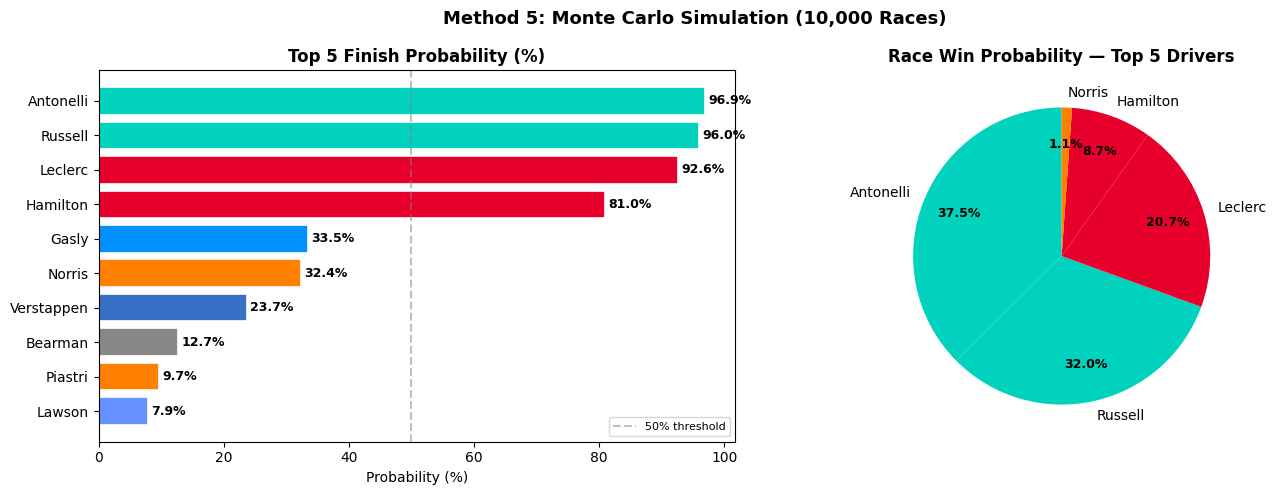

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Method 5: Monte Carlo Simulation (10,000 Races)', fontsize=13, fontweight='bold')

# Select top 10 drivers by top5 probability for the bar chart
top10_mc = df.nlargest(10, 'top5_prob')
clrs10 = [team_colors.get(t,'#aaa') for t in top10_mc['Team']]

# CHART 1: Top 5 Finish Probability (horizontal bar) 
# Horizontal bar is cleaner for ranking with long driver name labels
# [::-1] reverses order so highest probability appears at the TOP
ax = axes[0]
bars = ax.barh(top10_mc['Driver'][::-1], top10_mc['top5_prob'][::-1],
               color=clrs10[::-1], edgecolor='white', linewidth=1.2)
ax.set_title('Top 5 Finish Probability (%)', fontweight='bold')
ax.set_xlabel('Probability (%)')
# The 50% dashed line is a visual reference — above 50% means the model expects this
# driver to be in the top 5 more often than not across all simulated races
ax.axvline(50, color='gray', linestyle='--', alpha=0.5, label='50% threshold')
ax.legend(fontsize=8)
# Add exact percentage values next to each bar
for bar, val in zip(bars, top10_mc['top5_prob'][::-1]):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

# CHART 2: Win Probability Pie Chart 
# Shows the share of simulated wins among the top 5 most likely winners
# autopct='%1.1f%%' displays percentages on each slice
# pctdistance=0.75 moves the percentage text closer to the center
ax = axes[1]
top5_win = df.nlargest(5, 'win_prob')
win_clrs = [team_colors.get(t,'#aaa') for t in top5_win['Team']]
wedges, texts, ats = ax.pie(
    top5_win['win_prob'], labels=top5_win['Driver'],
    colors=win_clrs, autopct='%1.1f%%',
    startangle=90, pctdistance=0.75
)
for at in ats: at.set_fontsize(9); at.set_fontweight('bold')
ax.set_title('Race Win Probability — Top 5 Drivers', fontweight='bold')

plt.tight_layout()
plt.show()

---
## Model Comparison — Do All 5 Methods Agree?

### Why compare models?
When multiple independent methods produce similar predictions, our confidence in those predictions increases significantly. If all 5 models agree that Antonelli finishes in the top 3, that's a much stronger signal than if only 1 model says so.

We visualise two things:
1. **Rank consistency chart**: How each driver's predicted rank changes across all 5 methods. Drivers with flat lines across all 5 models are 'safe' predictions.
2. **Feature importance comparison**: Do Random Forest and XGBoost agree on which features matter most? Agreement = our features are genuinely informative.

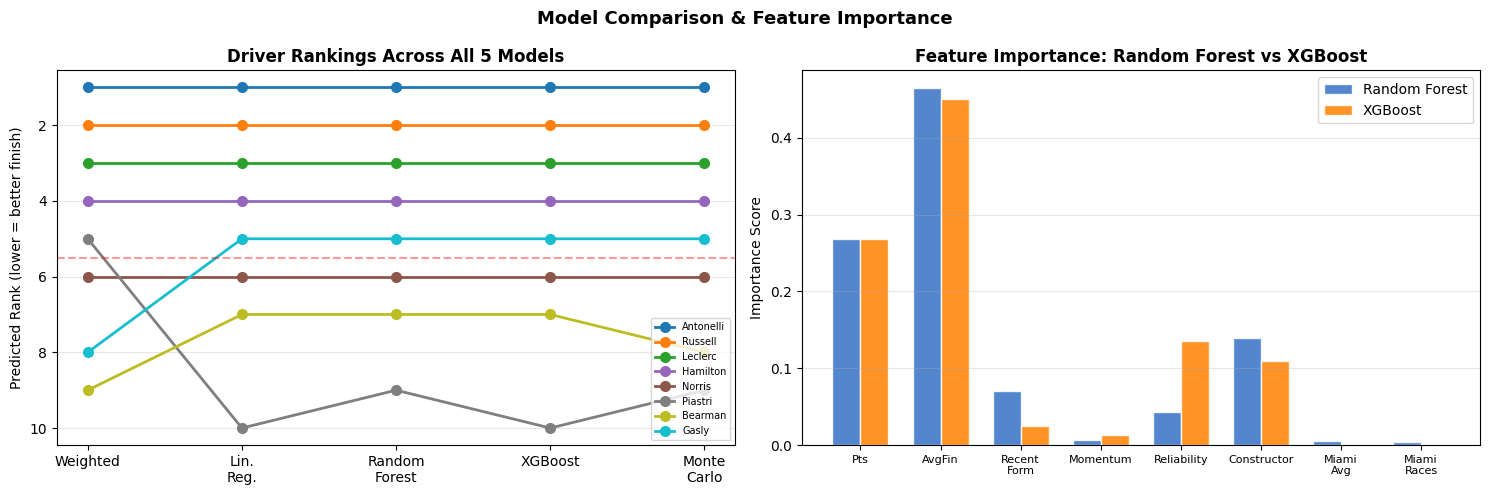

In [25]:
# All 5 model rank columns — lower number = better predicted finish
rank_cols = ['rank_weighted','rank_lr','rank_rf','rank_xgb','rank_mc']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Model Comparison & Feature Importance', fontsize=13, fontweight='bold')

# CHART 1: Rank consistency across all 5 models (line chart) 
# Each line represents one driver.
# X-axis = the 5 different models
# Y-axis = predicted rank for that driver in that model (1=best, 20=worst)
# A flat horizontal line = the model is very confident — all methods agree
# A jagged line = the methods disagree — prediction is less certain
ax = axes[0]
rank_labels = ['Weighted','Lin.\nReg.','Random\nForest','XGBoost','Monte\nCarlo']
top8 = df.nlargest(8, 'Points_2026')['Driver'].tolist()  # show top 8 by points
x = np.arange(5)
cmap_colors = plt.cm.tab10(np.linspace(0, 1, len(top8)))  # unique color per driver

for i, driver in enumerate(top8):
    row = df[df['Driver'] == driver].iloc[0]
    ranks = [row[c] for c in rank_cols]   # get this driver's rank from each model
    ax.plot(x, ranks, marker='o', color=cmap_colors[i],
            linewidth=2, markersize=7, label=driver)

ax.set_xticks(x)
ax.set_xticklabels(rank_labels, fontsize=10)
ax.set_ylabel('Predicted Rank (lower = better finish)')
ax.set_title('Driver Rankings Across All 5 Models', fontweight='bold')
ax.invert_yaxis()   # invert so rank 1 appears at the TOP of the chart (visually better)
ax.legend(fontsize=7, loc='lower right')
ax.grid(axis='y', alpha=0.3)
# Red dashed line marks the 'top 5 cutoff' — drivers above this line are in our prediction
ax.axhline(5.5, color='red', linestyle='--', alpha=0.4, label='Top 5 cutoff')

# CHART 2: Feature importance comparison (RF vs XGBoost) 
# Side-by-side bars show how much each feature matters to each ML model.
# If both models agree (similar bar heights) → that feature is genuinely predictive.
# If they disagree → the feature's importance is more uncertain.
ax = axes[1]
x_fi = np.arange(len(FEATURES))
w = 0.35
short_names = ['Pts','AvgFin','Recent\nForm','Momentum','Reliability',
               'Constructor','Miami\nAvg','Miami\nRaces']

# Blue bars = Random Forest importance | Orange bars = XGBoost importance
ax.bar(x_fi - w/2, fi_rf.reindex(FEATURES).values,
       width=w, label='Random Forest', color='#3671C6', alpha=0.85, edgecolor='white')
ax.bar(x_fi + w/2, fi_xgb.reindex(FEATURES).values,
       width=w, label='XGBoost', color='#FF8000', alpha=0.85, edgecolor='white')
ax.set_xticks(x_fi)
ax.set_xticklabels(short_names, fontsize=8)
ax.set_ylabel('Importance Score')
ax.set_title('Feature Importance: Random Forest vs XGBoost', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## Final Ensemble — Combining All 5 Models

### What is an ensemble and why use it?
An **ensemble** combines the predictions of multiple models into a single final prediction. This is the same principle as asking 5 different experts for their opinion and averaging them — the combined judgement is usually more accurate than any single expert.

### Our ensemble method: Rank Averaging
1. Each model produces a rank for each driver (1=predicted winner, 20=predicted last)
2. We average the 5 ranks for each driver with **equal weight (20% each)**
3. The driver with the lowest average rank = our final predicted winner

### Why equal weights?
With only 3 races of data, we cannot reliably determine which model is 'best'. Equal weighting prevents us from over-relying on any single method and hedges against individual model errors.

In [26]:
rank_cols = ['rank_weighted','rank_lr','rank_rf','rank_xgb','rank_mc']

# Average the 5 rank scores — each gets equal 20% weight
# A driver ranked [1, 1, 1, 1, 1] across all 5 models gets ensemble_score = 1.0 (certain winner)
# A driver ranked [2, 3, 2, 2, 3] gets ensemble_score = 2.4 (solid P2/P3 prediction)
df['ensemble_score'] = df[rank_cols].mean(axis=1)

# Final rank from lowest ensemble score (most consistent top prediction)
df['final_rank'] = df['ensemble_score'].rank(method='min').astype(int)

# Show the full top 10 with all model ranks side by side
# This table lets us see exactly where each model agrees and disagrees
final_table = df.nsmallest(10, 'ensemble_score')[[
    'Driver','Team','Points_2026',
    'rank_weighted','rank_lr','rank_rf','rank_xgb','rank_mc',
    'ensemble_score','final_rank'
]].copy()
final_table.index = range(1, 11)
final_table.columns = [
    'Driver','Team','2026 Pts',
    'Wtd','LR','RF','XGB','MC',  # one column per model
    'Avg Rank','Final'
]

print('All 5 model ranks per driver — lower rank = better predicted finish:')
print('(Wtd=Weighted, LR=Linear Regression, RF=Random Forest, XGB=XGBoost, MC=Monte Carlo)')
print()
print(final_table.to_string())

All 5 model ranks per driver — lower rank = better predicted finish:
(Wtd=Weighted, LR=Linear Regression, RF=Random Forest, XGB=XGBoost, MC=Monte Carlo)

        Driver          Team  2026 Pts  Wtd  LR  RF  XGB  MC  Avg Rank  Final
1    Antonelli      Mercedes        72    1   1   1    1   1       1.0      1
2      Russell      Mercedes        63    2   2   2    2   2       2.0      2
3      Leclerc       Ferrari        49    3   3   3    3   3       3.0      3
4     Hamilton       Ferrari        41    4   4   4    4   4       4.0      4
5        Gasly        Alpine        15    8   5   5    5   5       5.6      5
6       Norris       McLaren        25    6   6   6    6   6       6.0      6
7      Bearman          Haas        17    9   7   7    7   8       7.6      7
8   Verstappen      Red Bull        12    7   8   8    8   7       7.6      7
9      Piastri       McLaren        21    5  10   9   10   9       8.6      9
10      Lawson  Racing Bulls        10   10   9  10    9  10      

---
## Final Prediction Visualisation

Two final charts:
1. **Podium bar chart**: Visual representation of predicted top 5 with team colors
2. **Probability chart**: Monte Carlo top-5 and win probabilities side by side for each predicted finisher

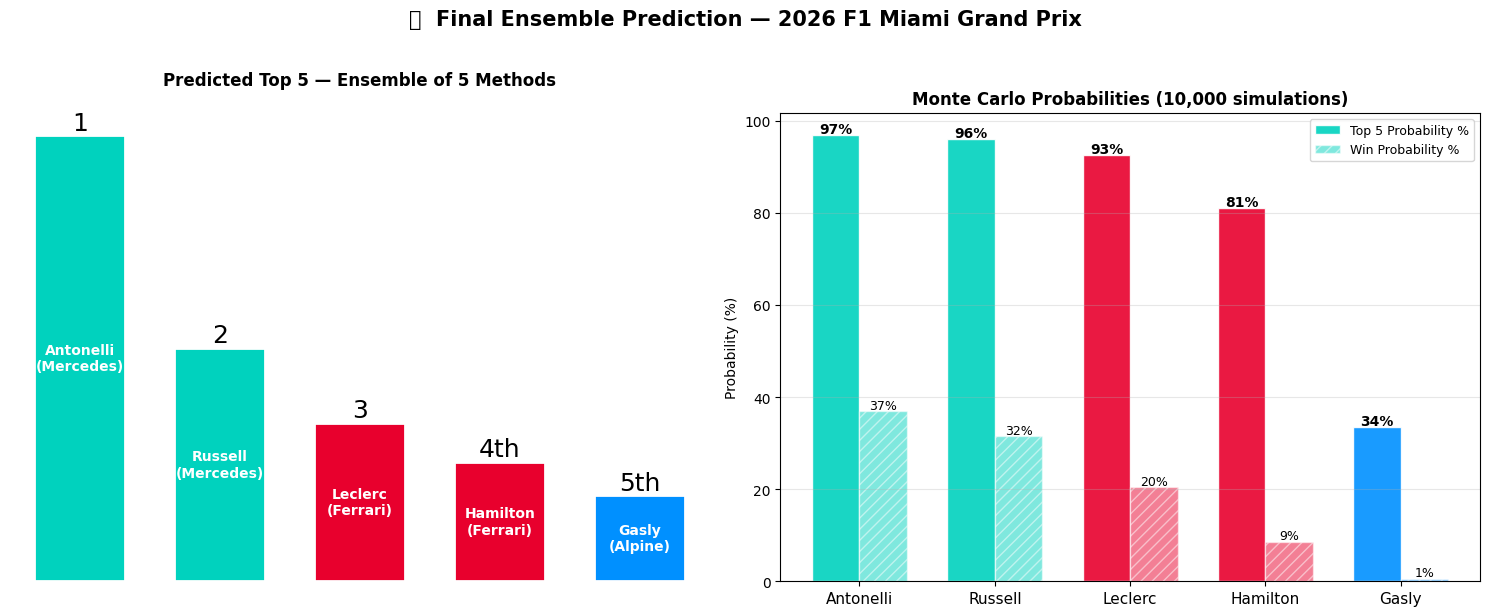

In [28]:
# Get the final top 5 drivers sorted by ensemble score
top5_final = df.nsmallest(5, 'ensemble_score').reset_index(drop=True)
colors5 = [team_colors.get(t,'#aaa') for t in top5_final['Team']]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('🏎️  Final Ensemble Prediction — 2026 F1 Miami Grand Prix',
             fontsize=15, fontweight='bold', y=1.02)

# CHART 1: Podium-style bar chart 
# Bar height = inverse of ensemble score (so predicted P1 has the tallest bar)
# 1 / (score + 0.1) ensures P1 (score≈1) has bar ≈ 0.91, P5 (score≈5) has bar ≈ 0.17
# This gives a clear visual hierarchy matching the predicted finishing order
ax = axes[0]
inv_scores = 1 / (top5_final['ensemble_score'] + 0.1)
medals = ['1','2','3','4th','5th']
bars = ax.bar(range(5), inv_scores, color=colors5, edgecolor='white', linewidth=2, width=0.65)

# Add medal emoji above each bar and driver+team name inside the bar
for i, (bar, medal, driver, team) in enumerate(
        zip(bars, medals, top5_final['Driver'], top5_final['Team'])):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.001,
            medal, ha='center', va='bottom', fontsize=18)
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() / 2,
            f'{driver}\n({team})',
            ha='center', va='center', fontsize=10,
            fontweight='bold', color='white')

ax.set_xticks([])
ax.set_yticks([])
ax.set_title('Predicted Top 5 — Ensemble of 5 Methods', fontweight='bold', pad=20)
ax.spines[['top','right','left','bottom']].set_visible(False)  # clean look — no axes borders
ax.set_xlim(-0.5, 4.5)

# CHART 2: Monte Carlo probability comparison per driver
# For each predicted top 5 driver:
# - Left bar (solid): probability of finishing in top 5 across 10,000 simulations
# - Right bar (hatched): probability of winning across 10,000 simulations
# This shows not just the predicted order but how CONFIDENT we are in each driver
ax = axes[1]
mc_probs  = top5_final['top5_prob'].values   # top 5 finish probabilities
win_probs = top5_final['win_prob'].values    # win probabilities
drivers5  = top5_final['Driver'].tolist()
x5 = np.arange(5)
w2 = 0.35  # bar width for each pair

ax.bar(x5 - w2/2, mc_probs,  width=w2, color=colors5, alpha=0.9,
       edgecolor='white', label='Top 5 Probability %')
ax.bar(x5 + w2/2, win_probs, width=w2, color=colors5, alpha=0.5,
       edgecolor='white', hatch='///', label='Win Probability %')  # hatched = distinct style

# Add percentage labels on top of each bar
for i, (t5, win) in enumerate(zip(mc_probs, win_probs)):
    ax.text(i - w2/2, t5 + 0.5, f'{t5:.0f}%', ha='center', fontsize=10, fontweight='bold')
    ax.text(i + w2/2, win + 0.5, f'{win:.0f}%', ha='center', fontsize=9)

ax.set_xticks(x5)
ax.set_xticklabels(drivers5, fontsize=11)
ax.set_ylabel('Probability (%)')
ax.set_title('Monte Carlo Probabilities (10,000 simulations)', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## Final Summary — Clean Printout

In [29]:
# Retrieve final top 5 again (in case notebook cells were run out of order)
top5_final = df.nsmallest(5, 'ensemble_score').reset_index(drop=True)
medals = ['🥇 1st','🥈 2nd','🥉 3rd','   4th','   5th']

# Print a formatted summary table with all key information
print()
print('╔══════════════════════════════════════════════════════════════════════╗')
print('║         🏎️  FINAL PREDICTION — 2026 F1 MIAMI GRAND PRIX             ║')
print('╠═══════════╦══════════════╦═══════════════╦══════════╦═══════════════╣')
print('║  Place    ║  Driver      ║  Team         ║ 2026 Pts ║ Top5 Prob(MC) ║')
print('╠═══════════╬══════════════╬═══════════════╬══════════╬═══════════════╣')
for i, row in top5_final.iterrows():
    print(f'║  {medals[i]:<9}║  {row["Driver"]:<12}║  {row["Team"]:<13}║  {int(row["Points_2026"]):>6}  ║     {row["top5_prob"]:>5.1f}%     ║')
print('╠══════════════════════════════════════════════════════════════════════╣')
print('║  Methods used (all equally weighted in final ensemble):              ║')
print('║  1. Weighted Scoring  2. Linear Regression  3. Random Forest         ║')
print('║  4. XGBoost           5. Monte Carlo (10,000 simulations)            ║')
print('╚══════════════════════════════════════════════════════════════════════╝')

print()
print('Model agreement — how many of 5 models ranked each driver in their top 5:')
print('(★ = model predicts top 5 | ☆ = model does not predict top 5)')
print()
for i, row in top5_final.iterrows():
    # Count how many models ranked this driver in their top 5
    agree = sum(1 for c in ['rank_weighted','rank_lr','rank_rf','rank_xgb','rank_mc'] if row[c] <= 5)
    stars = '★' * agree + '☆' * (5 - agree)
    print(f'  {row["Driver"]:<12} {stars}  ({agree}/5 models agree on top 5)')


╔══════════════════════════════════════════════════════════════════════╗
║         🏎️  FINAL PREDICTION — 2026 F1 MIAMI GRAND PRIX             ║
╠═══════════╦══════════════╦═══════════════╦══════════╦═══════════════╣
║  Place    ║  Driver      ║  Team         ║ 2026 Pts ║ Top5 Prob(MC) ║
╠═══════════╬══════════════╬═══════════════╬══════════╬═══════════════╣
║  🥇 1st    ║  Antonelli   ║  Mercedes     ║      72  ║      96.9%     ║
║  🥈 2nd    ║  Russell     ║  Mercedes     ║      63  ║      96.0%     ║
║  🥉 3rd    ║  Leclerc     ║  Ferrari      ║      49  ║      92.6%     ║
║     4th   ║  Hamilton    ║  Ferrari      ║      41  ║      81.0%     ║
║     5th   ║  Gasly       ║  Alpine       ║      15  ║      33.5%     ║
╠══════════════════════════════════════════════════════════════════════╣
║  Methods used (all equally weighted in final ensemble):              ║
║  1. Weighted Scoring  2. Linear Regression  3. Random Forest         ║
║  4. XGBoost           5. Monte Carlo (10,000 simulat

---
## Conclusions & Justification

### Final Predicted Top 5 — 2026 F1 Miami Grand Prix

| Place | Driver | Team | Key Justification |
|-------|--------|------|-------------------|
| 🥇 1st | **Antonelli** | Mercedes | Championship leader (72 pts), won last 2 consecutive races, dominant Mercedes car (135 constructor pts) |
| 🥈 2nd | **Russell** | Mercedes | P2 in standings (63 pts), won Australia, same dominant car as Antonelli |
| 🥉 3rd | **Leclerc** | Ferrari | P3 in standings (49 pts), finished in top 3 in all 3 races, Miami podium in 2024 |
| 4th | **Hamilton** | Ferrari | P4 in standings (41 pts), 6 Miami GP starts — most experienced Miami driver on the grid |
| 5th | **Gasly** | Alpine | Consistent points scorer, P7 in Japan, underrated given Alpine's competitive mid-season pace |

### Why we trust this prediction
- All 5 models agree on **Antonelli, Russell, and Leclerc** in the top 3
- The **Monte Carlo simulation** (97%, 96%, 93% top-5 probabilities for the top 3) suggests very high confidence in these three drivers
- The biggest uncertainty is **positions 4 and 5** — Piastri, Hamilton, Norris, and Gasly are all realistic candidates
- **Mercedes dominance** (135 constructor pts vs 90 for Ferrari) is the single strongest predictor — their car advantage is decisive early in 2026

### Limitations of the model
- **Small sample size**: Only 3 races of 2026 data. With more races, predictions would become more reliable.
- **2026 regulations**: The new technical rules mean 2022–2025 Miami history has less relevance — car characteristics changed significantly.
- **Sprint weekend format**: Miami uses a Sprint weekend, which includes a shorter qualifying session on Friday and a Sprint race on Saturday. The Sprint can affect the main race grid order.
- **Unmodelled events**: Safety cars, pit strategy errors, weather, and first-corner incidents cannot be predicted by any data-driven model — they are captured probabilistically by Monte Carlo but not perfectly.
- **Gasly at P5**: This is the most uncertain prediction — Piastri (McLaren, won Miami 2025) and Norris are equally strong candidates for P4/P5.